In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [121]:
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\train.csv")

In [122]:
print(df.head(5))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [123]:
print(df.isnull())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

In [124]:
df = df[['Survived','Pclass','Sex','Age','Fare']]

In [125]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [126]:
df['Age'].fillna(df['Age'].mean(),inplace= True)

C:\Users\Saniya\AppData\Local\Temp\ipykernel_20304\1280160446.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace= True)


In [127]:
x = df[['Pclass','Age','Sex','Fare']].values
y = df['Survived'].values

In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(x)

In [129]:
from sklearn.model_selection import train_test_split

X_train,X_test , y_train,y_test = train_test_split(
    X , y , test_size=0.2, random_state= 42
) 

In [130]:
m,n = X.shape

w = np.zeros(n)
b = 0


In [131]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [135]:
def compute_cost(X_train,y_train,w,b):
    m = len(y_train)

    z = np.dot(X_train,w)+b
    y_hat = sigmoid(z)

    cost = -np.mean(y_train*np.log(y_hat) + (1-y_train)*np.log(1-y_hat))
    return cost

In [136]:
m = len(y_train)
learning_rate = 0.1

epochs = 1000

for i in range(epochs):
    z = np.dot(X_train,w)+b

    y_hat = sigmoid(z)

    dw = np.dot(X_train.T,(y_hat-y_train))/m
    db = np.sum(y_hat - y_train)/m

    w = w - learning_rate*dw
    b = b - learning_rate*db

    if i % 100 == 0:
        print("Cost of iteration",i,":",compute_cost(X_train,y_train,w,b))




Cost of iteration 0 : 0.4600262956970382
Cost of iteration 100 : 0.46002629569337017
Cost of iteration 200 : 0.4600262956922938
Cost of iteration 300 : 0.4600262956919779
Cost of iteration 400 : 0.4600262956918852
Cost of iteration 500 : 0.46002629569185804
Cost of iteration 600 : 0.4600262956918501
Cost of iteration 700 : 0.4600262956918477
Cost of iteration 800 : 0.46002629569184705
Cost of iteration 900 : 0.4600262956918469


In [137]:
def predict (X_train,w,b):
    z = np.dot(X_test,w)+b
    y_hat = sigmoid(z)

    return (y_hat>=0.5).astype(int)

In [138]:
y_pred = predict(X_train,w,b)

accuracy = np.mean(y_pred == y_test)

In [139]:
print("accuracy: ",accuracy)

accuracy:  0.7988826815642458


In [141]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[89 16]
 [20 54]]


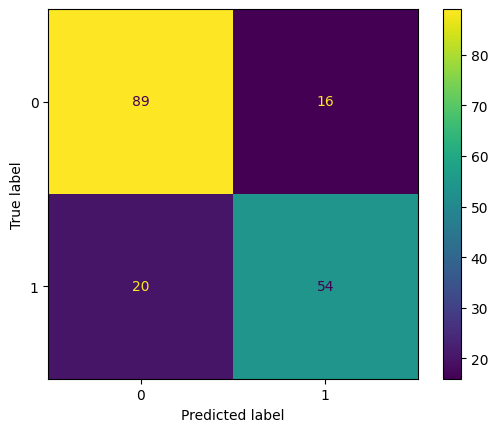

In [143]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()